Random_state:  38
   Exudate Cell n. slope  V2 -  No.of M1 Exudate  V2 -  N0. of M1 dressing  \
1             -1000000.0                      20                       100   
8                13509.0                      29                         4   

   V 3 - No. of M2 Exudate  V 3 -  No. of M2 dressing  CD105 Slope  \
1                       32                         10           54   
8                      100                         31           43   

   Collagen slope  
1           2.246  
8          -9.496  
[[0. 1.]
 [1. 0.]]
              precision    recall  f1-score   support

     healing       0.00      0.00      0.00         1
 Not-healing       0.50      1.00      0.67         1

   micro avg       0.50      0.50      0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2
 samples avg       0.50      0.50      0.50         2



C:\Users\natej\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


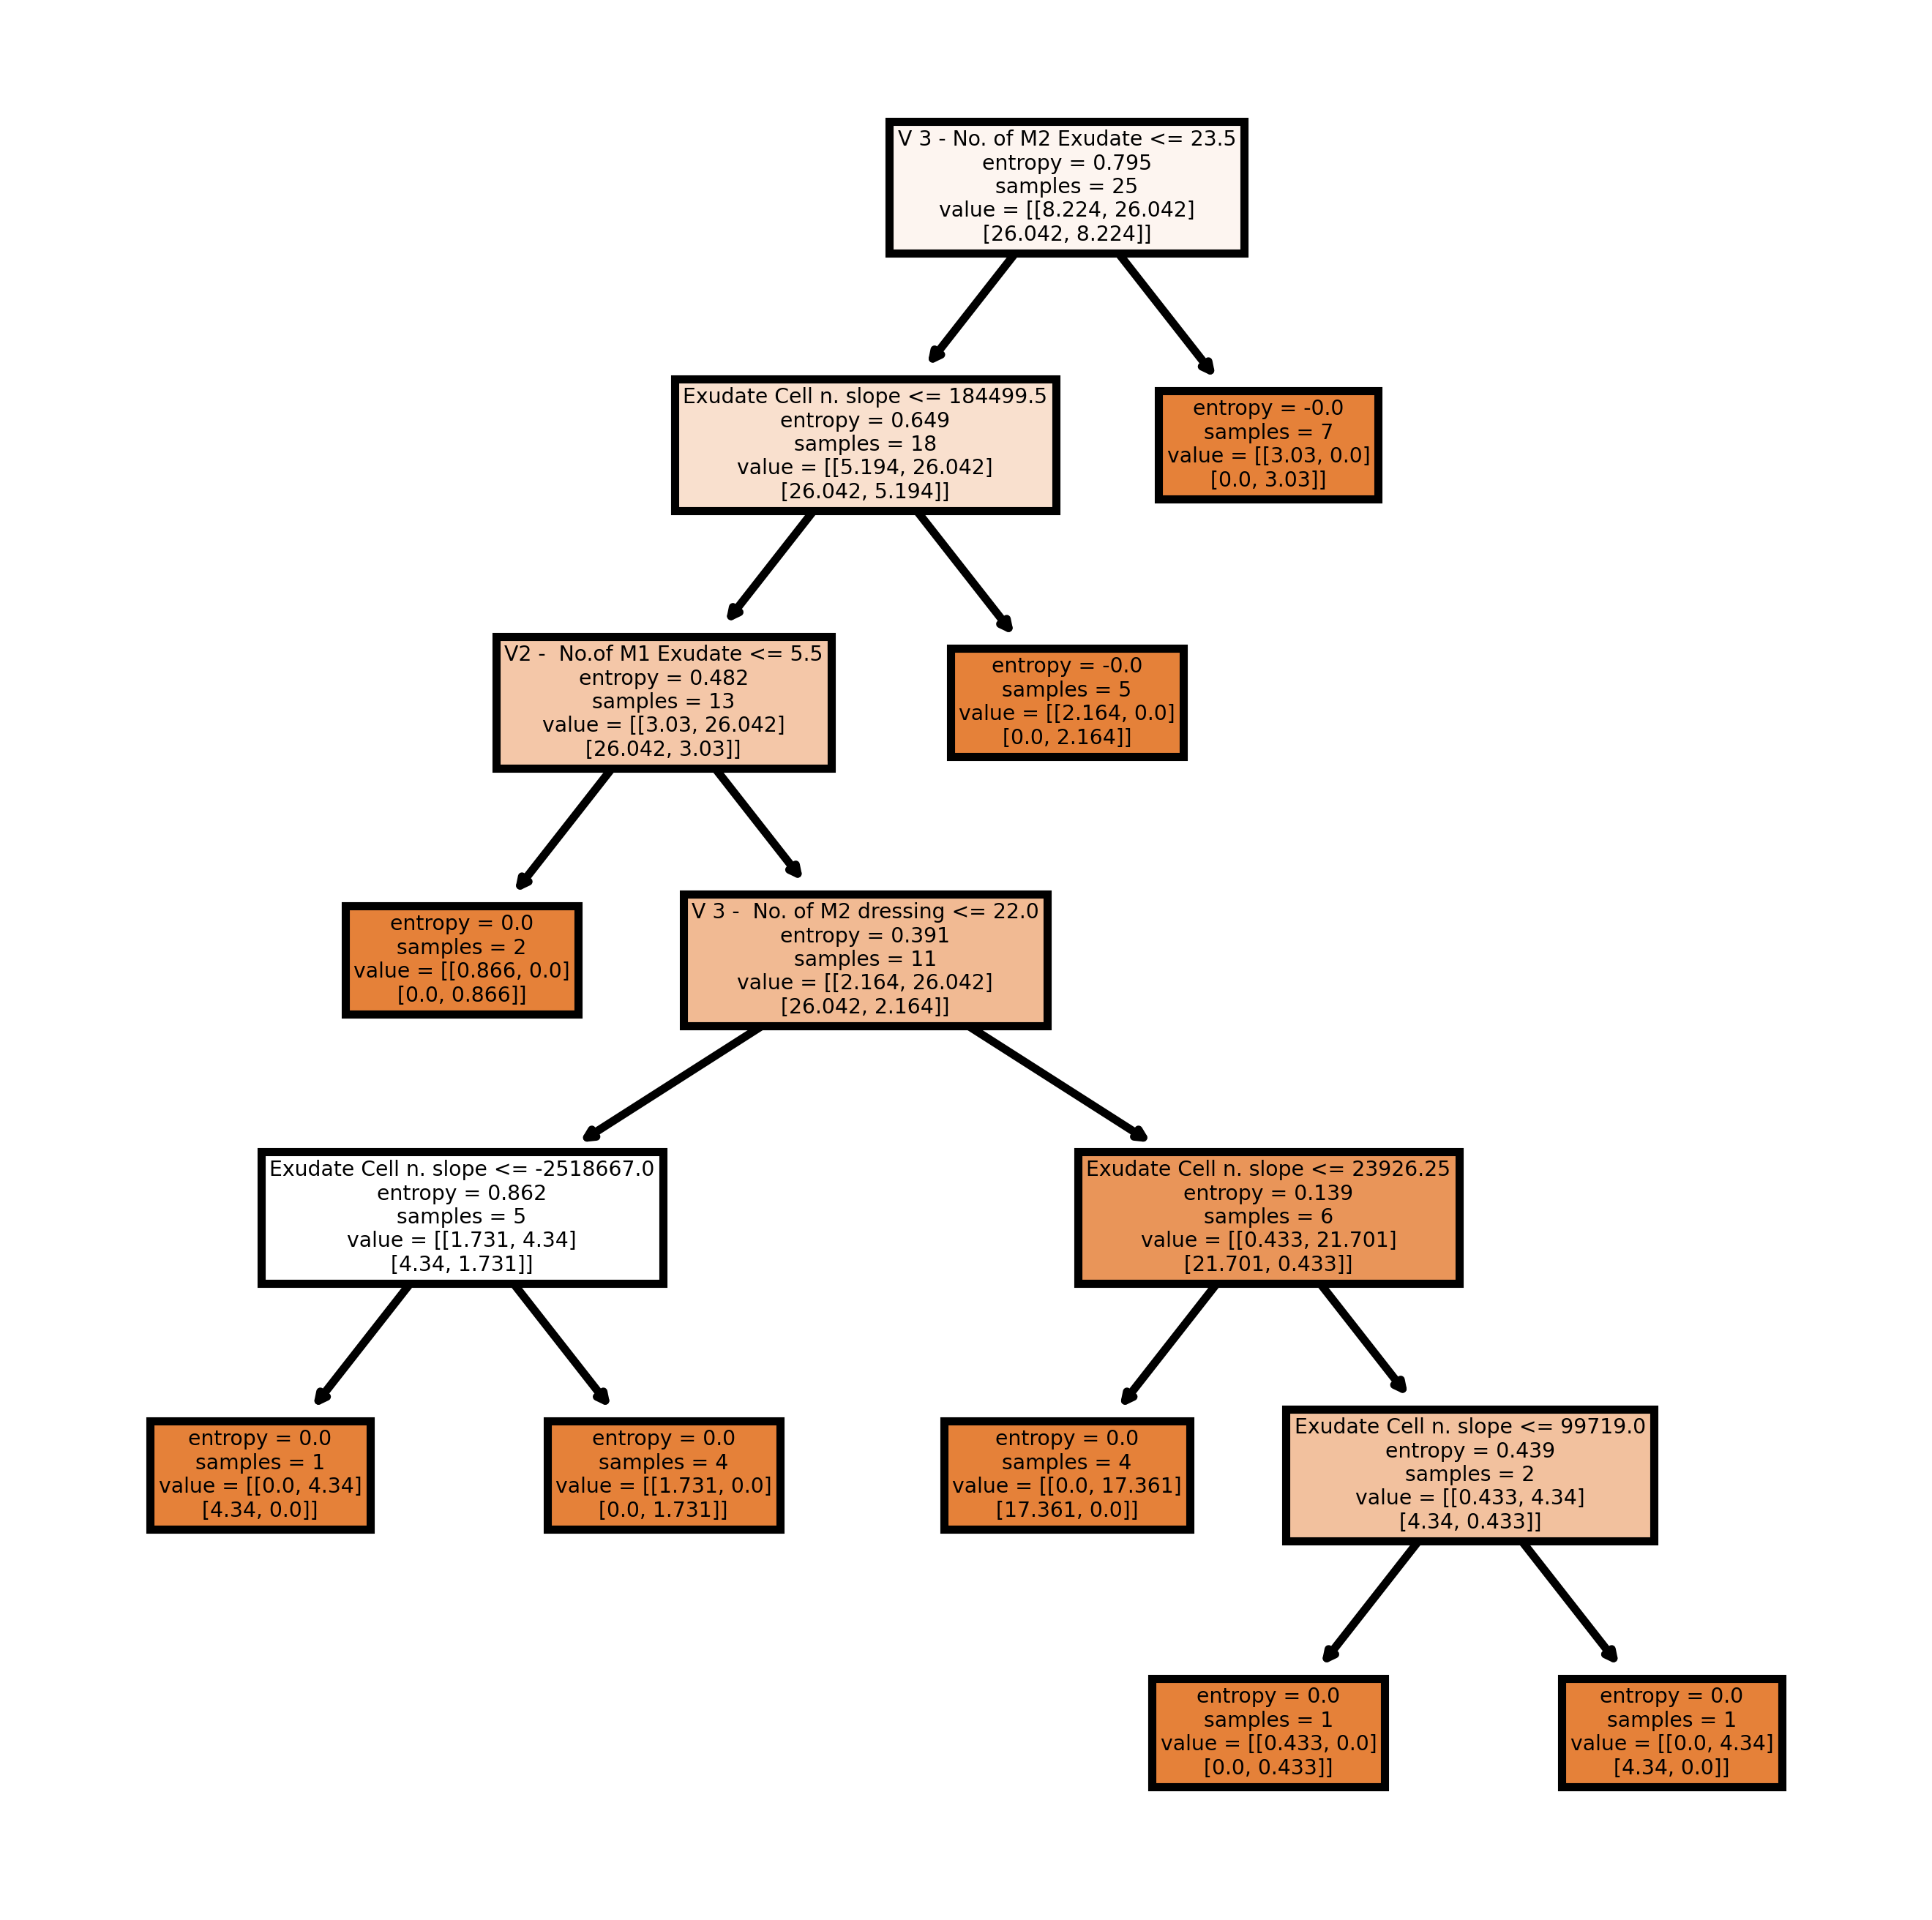

Accuracy: 50.0 %


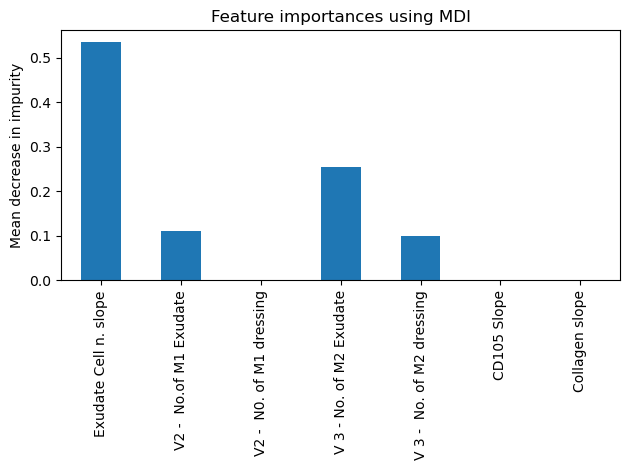

----------------------------------------------------------------------------------------------------------------------------------------


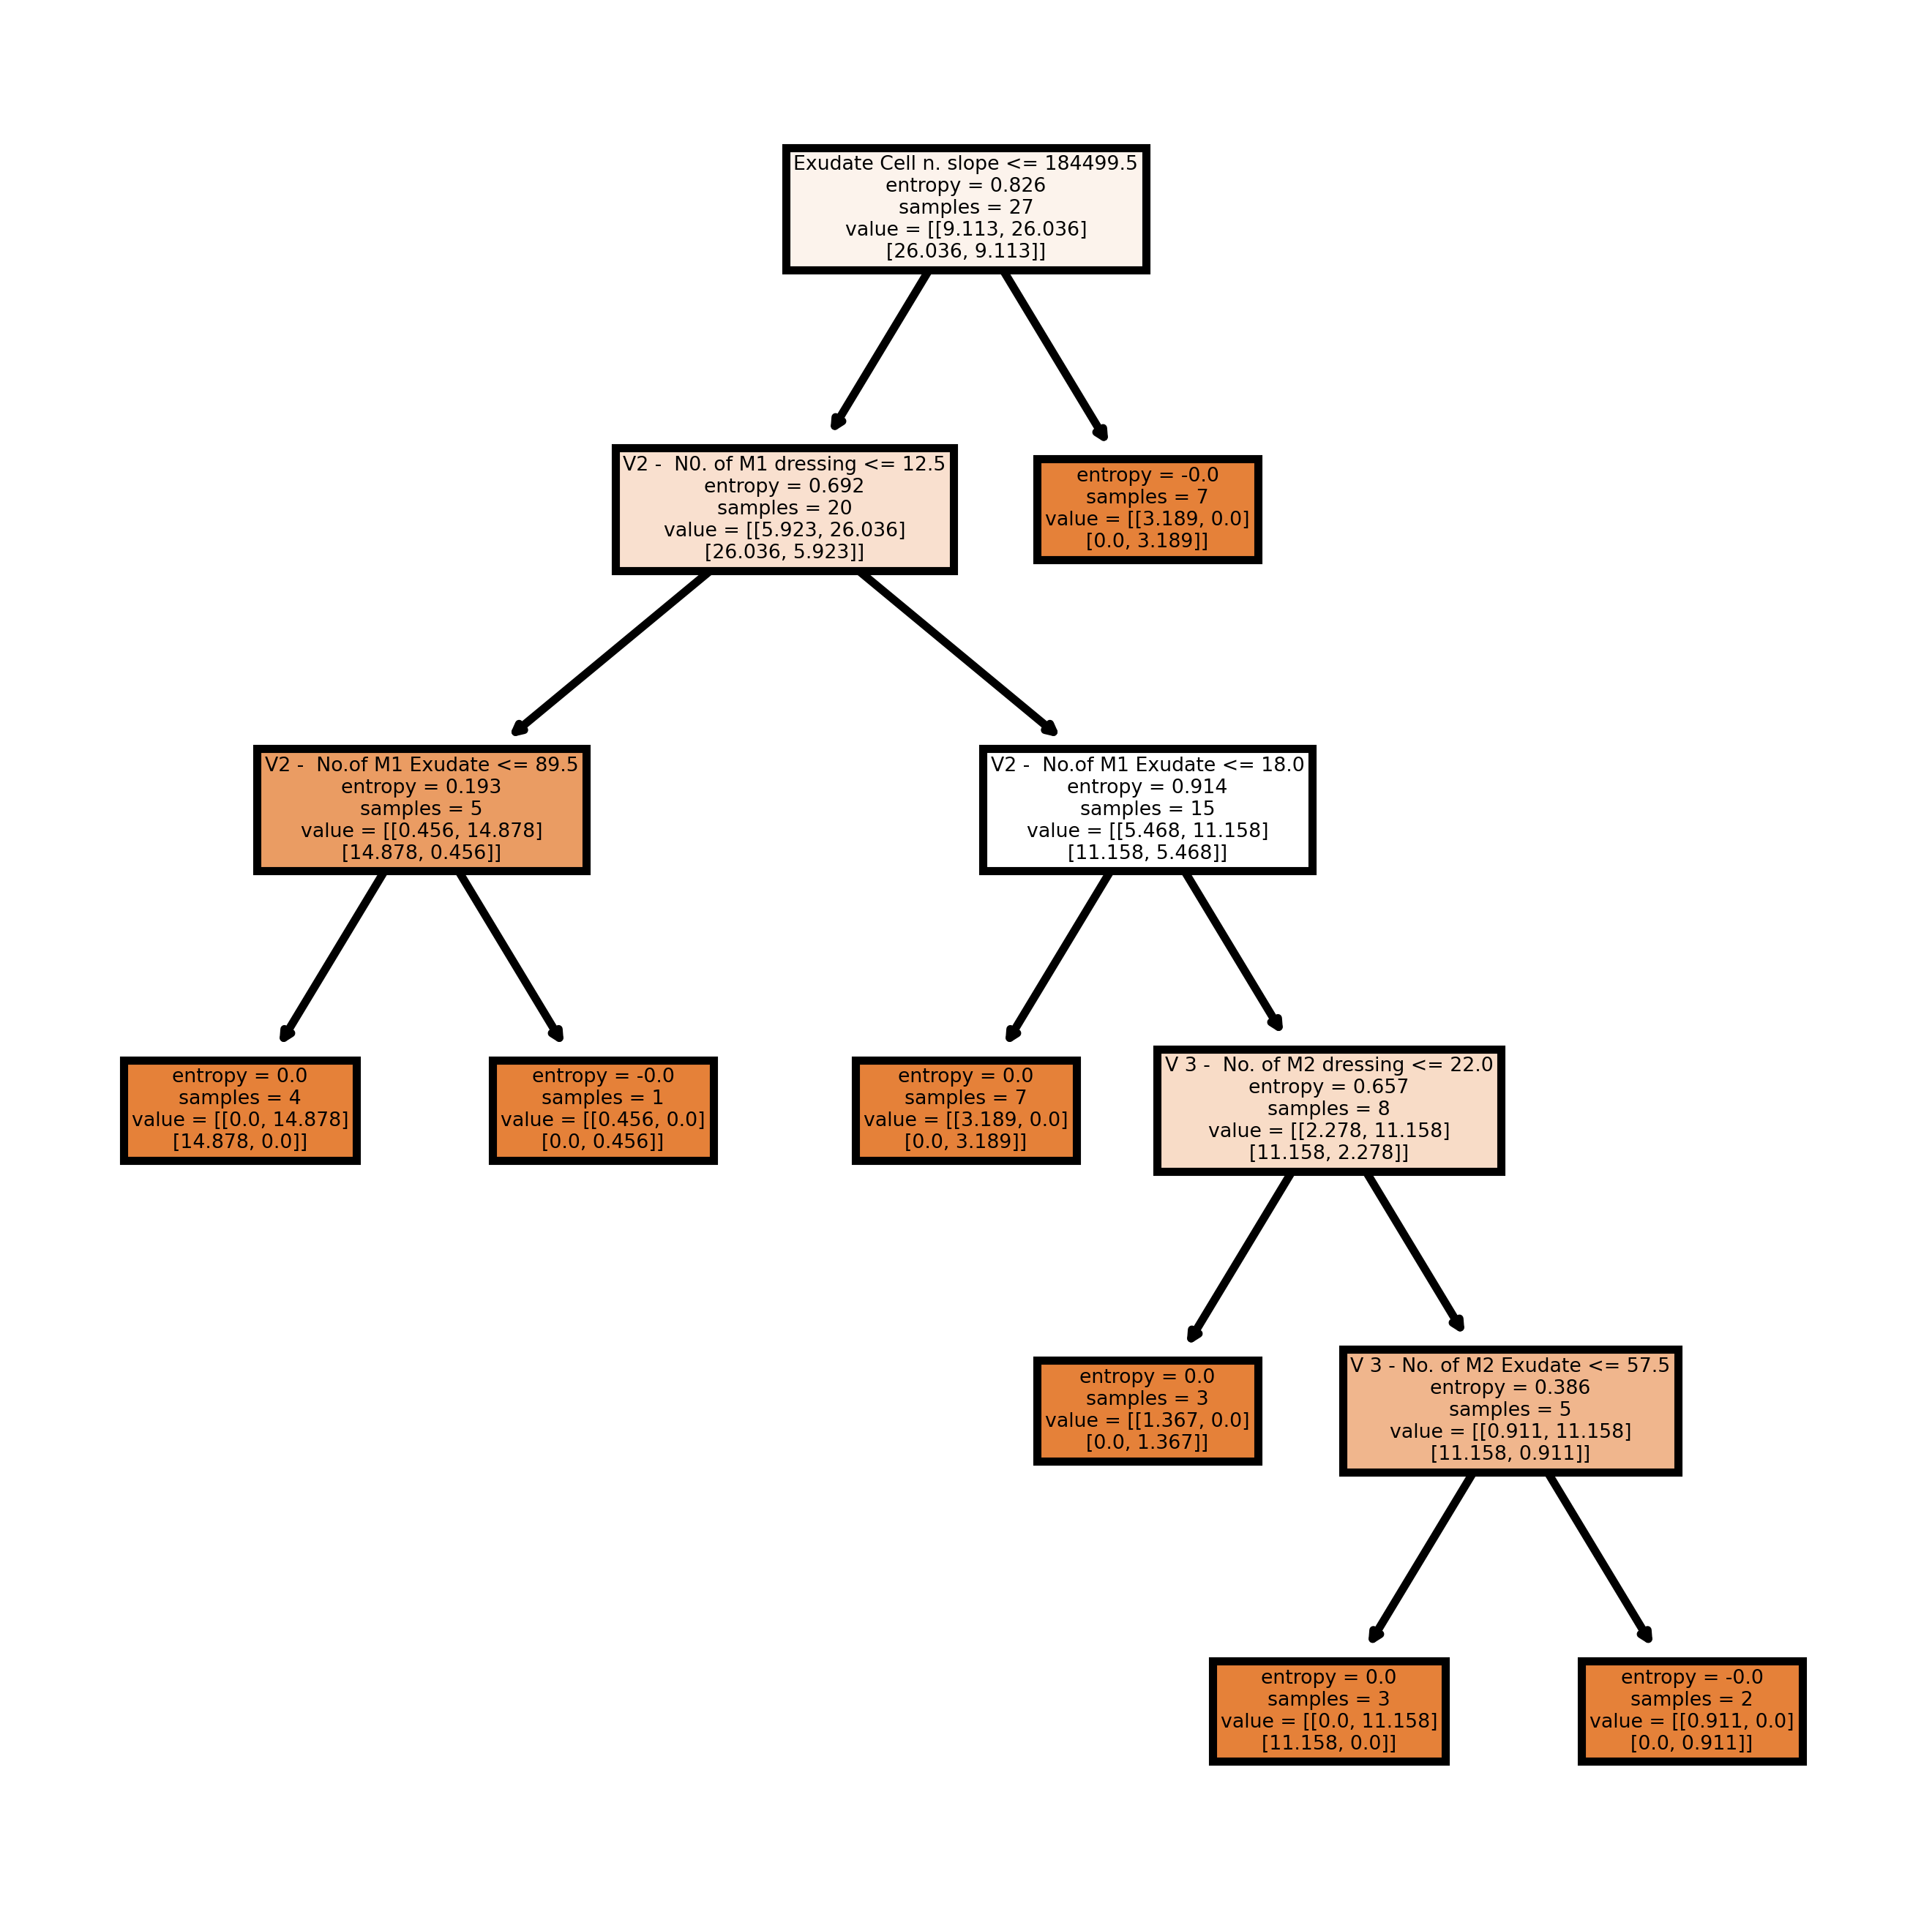

Accuracy: 100.0 %
              precision    recall  f1-score   support

     healing       1.00      1.00      1.00         7
 Not-healing       1.00      1.00      1.00        20

   micro avg       1.00      1.00      1.00        27
   macro avg       1.00      1.00      1.00        27
weighted avg       1.00      1.00      1.00        27
 samples avg       1.00      1.00      1.00        27



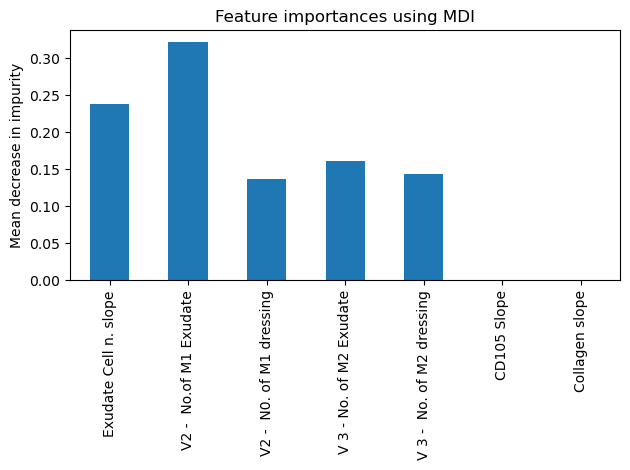

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier

Treatment=pd.read_csv("../dissertation/Atrauman Correlation Analyses.csv")
df_x=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]
R_state=random.randrange(1,100)
print("Random_state: ",R_state)
#R_state=9
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y,test_size=0.06, random_state=R_state,stratify=df_y)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
print(X_test)
print(y_test)

names=["Exudate Cell n. slope","V2 -  No.of M1 Exudate","V2 -  N0. of M1 dressing","V 3 - No. of M2 Exudate","V 3 -  No. of M2 dressing","CD105 Slope","Collagen slope"]



clf=DecisionTreeClassifier(max_depth=None,
                            class_weight="balanced",
                               criterion="entropy",
                              ccp_alpha=0.03,
                  
    )

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 

print(classification_report(y_test,y_pred,output_dict=False,target_names=["healing","Not-healing"]))

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)

tree.plot_tree(clf, filled = True,feature_names=names);
#plt.savefig('Tree', dpi=1200)
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)
fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

print("----------------------------------------------------------------------------------------------------------------------------------------")

df_y = to_categorical(df_y)
clf.fit(df_x,df_y)
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)

tree.plot_tree(clf, filled = True,feature_names=names);
#plt.savefig('Tree', dpi=1200)
plt.show()
y_pred = clf.predict(df_x)
y_pred = (y_pred > 0.5) 
accuracy = accuracy_score(df_y, y_pred)
print("Accuracy:", (accuracy*100),"%")
print(classification_report(df_y,y_pred,output_dict=False,target_names=["healing","Not-healing"]))

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)
fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()